# 01 — Exploration et nettoyage
Projet E : Credit Risk Scoring (Lending Club)

Objectif de ce notebook :
- Charger le dataset Lending Club (prêts acceptés uniquement)
- Filtrer sur les prêts soldés et la fenêtre d'années cible
- Nettoyer et documenter l'exclusion des variables à risque de data leakage
- Construire les features de base pour la modélisation PD (notebook 02)

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import (
    FEATURE_COLUMNS, LEAKAGE_COLUMNS, CLOSED_STATUSES, DEFAULT_STATUSES,
    load_and_filter, filter_closed_loans, add_target, select_features
)
from src.features import build_features

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Chargement des données

Le fichier `accepted_2007_to_2018Q4.csv` pèse ~1,6 Go : chargé et filtré par blocs
via `load_and_filter` (prêts soldés, années 2007-2017), puis sauvegardé en parquet.

Volume final : 1 289 032 lignes, taux de défaut 20,15%.

Le fichier `rejected_2007_to_2018Q4.csv` n'est pas utilisé (prêts jamais financés,
aucun historique de performance).

In [2]:
df = load_and_filter("../data/raw/accepted_2007_to_2018Q4.csv", year_min=2007, year_max=2017)
df = add_target(df)

print(f"\nLignes finales : {df.shape[0]:,}".replace(",", " "))
print("\nRépartition de la cible (default) :")
print(df["default"].value_counts(normalize=True))

print("\nRépartition par année :")
print(df["issue_d"].dt.year.value_counts().sort_index())

Bloc 1 traité — lignes conservées cumulées : 176 083
Bloc 2 traité — lignes conservées cumulées : 356 181
Bloc 3 traité — lignes conservées cumulées : 399 852
Bloc 4 traité — lignes conservées cumulées : 482 349
Bloc 5 traité — lignes conservées cumulées : 538 655
Bloc 6 traité — lignes conservées cumulées : 715 452
Bloc 7 traité — lignes conservées cumulées : 861 878
Bloc 8 traité — lignes conservées cumulées : 861 878
Bloc 9 traité — lignes conservées cumulées : 997 330
Bloc 10 traité — lignes conservées cumulées : 1 173 545
Bloc 11 traité — lignes conservées cumulées : 1 254 625
Bloc 12 traité — lignes conservées cumulées : 1 289 032

Lignes finales : 1 289 032

Répartition de la cible (default) :
default
0    0.798512
1    0.201488
Name: proportion, dtype: float64

Répartition par année :
issue_d
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
Name: count, dtype: int

In [3]:
float_cols = df.select_dtypes(include="float64").columns
df[float_cols] = df[float_cols].astype("float32")

df.to_parquet("../data/processed/accepted_filtered_2007_2017.parquet", index=False)
print(f"Sauvegardé : {df.shape[0]:,} lignes, {df.memory_usage(deep=True).sum() / 1e6:.0f} Mo en mémoire".replace(",", " "))

Sauvegardé — 1 289 032 lignes  217 Mo en mémoire


In [15]:
df = pd.read_parquet("../data/processed/accepted_filtered_2007_2017.parquet")
print(f"Lignes chargées : {df.shape[0]:,}".replace(",", " "))
df["default"].value_counts(normalize=True)

Lignes chargées : 1 289 032


default
0    0.798512
1    0.201488
Name: proportion, dtype: float64

## 2. Exclusion des variables à risque de data leakage

Les colonnes suivantes sont connues **seulement après l'octroi** du prêt et ne doivent
jamais servir à prédire le défaut (data leakage) :

- `total_pymnt`, `total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`
  → montants effectivement remboursés, connus au fil du temps, pas à l'octroi
- `recoveries`, `collection_recovery_fee`
  → montants recouvrés après un défaut, donc postérieurs à l'événement à prédire
- `out_prncp`, `out_prncp_inv`
  → solde restant dû à un instant donné, évolue après l'octroi
- `last_pymnt_d`, `last_pymnt_amnt`, `next_pymnt_d`
  → dates/montants de paiements réalisés après l'octroi
- `last_fico_range_high/low`
  → score FICO mis à jour en cours de vie du prêt (contrairement à `fico_range_high/low`
    initial, qui lui est autorisé)
- `hardship_*`, `settlement_*`
  → statut de renégociation, connu uniquement après coup

Ces colonnes restent disponibles dans `df` pour le calcul de LGD/EAD au notebook 03,
mais sont explicitement retirées du jeu de features PD ci-dessous.

In [16]:
leakage_present = [c for c in LEAKAGE_COLUMNS if c in df.columns]
print("Colonnes de leakage présentes et exclues du modèle PD :")
print(leakage_present)

# Jeu de features autorisé pour la modélisation PD (anti-leakage)
df_features = select_features(df)
print(f"\nColonnes retenues pour la modélisation PD : {df_features.shape[1]}")
df_features.columns.tolist()

Colonnes de leakage présentes et exclues du modèle PD :
['total_pymnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']

Colonnes retenues pour la modélisation PD : 26


['loan_amnt',
 'funded_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'dti',
 'purpose',
 'fico_range_low',
 'fico_range_high',
 'open_acc',
 'total_acc',
 'revol_bal',
 'revol_util',
 'delinq_2yrs',
 'inq_last_6mths',
 'pub_rec',
 'earliest_cr_line',
 'issue_d',
 'loan_status',
 'default']

## 3. Valeurs manquantes et typage

In [17]:
missing = df_features.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print("Taux de valeurs manquantes par colonne :")
print(missing)

Taux de valeurs manquantes par colonne :
emp_length        5.708314e-02
revol_util        6.074326e-04
dti               1.729980e-04
inq_last_6mths    7.757759e-07
dtype: float64


In [18]:
# emp_length : catégorielle avec valeurs manquantes -> catégorie explicite "Unknown"
# (il faut d'abord déclarer la nouvelle catégorie avant de l'utiliser)
df_features["emp_length"] = df_features["emp_length"].cat.add_categories("Unknown")
df_features["emp_length"] = df_features["emp_length"].fillna("Unknown")

# revol_util : numérique, peu de manquants -> imputation par la médiane
df_features["revol_util"] = df_features["revol_util"].fillna(df_features["revol_util"].median())
df_features["inq_last_6mths"] = df_features["inq_last_6mths"].fillna(df_features["inq_last_6mths"].median())

# dti : idem
df_features["dti"] = df_features["dti"].fillna(df_features["dti"].median())

# Vérification finale
remaining_na = df_features.isna().sum()
print("Colonnes avec valeurs manquantes restantes :")
print(remaining_na[remaining_na > 0])

Colonnes avec valeurs manquantes restantes :
Series([], dtype: int64)


## 4. Feature engineering

- `credit_age_years` : ancienneté du dossier de crédit
- `loan_to_income` : montant du prêt rapporté au revenu annuel
- `grade_ordinal` : encodage ordinal du grade (A→G, hiérarchie de risque déjà présente)
- One-hot encoding de `purpose`, `home_ownership`, `verification_status`

In [19]:
# On repasse issue_d et earliest_cr_line depuis df (retirés de df_features par select_features)

df_features["issue_d"] = df["issue_d"].values
df_features["earliest_cr_line"] = df["earliest_cr_line"].values

df_features = build_features(df_features)

print(f"Colonnes après feature engineering : {df_features.shape[1]}")
df_features[["credit_age_years", "loan_to_income", "grade_ordinal"]].describe()

C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")


Colonnes après feature engineering : 46


,credit_age_years,loan_to_income
count,1.289032e+06,1.288819e+06
mean,1.627445e+01,3.622736e-01
std,7.498208e+00,6.257876e+01
min,2.997947e+00,1.714286e-04
25%,1.124709e+01,1.250000e-01
50%,1.474880e+01,2.000000e-01
75%,2.008214e+01,2.909091e-01
max,8.324983e+01,4.000000e+04


## 5. Exploration 

Distribution de la cible et de quelques variables clés, pour vérifier la cohérence
avant de passer à la modélisation.

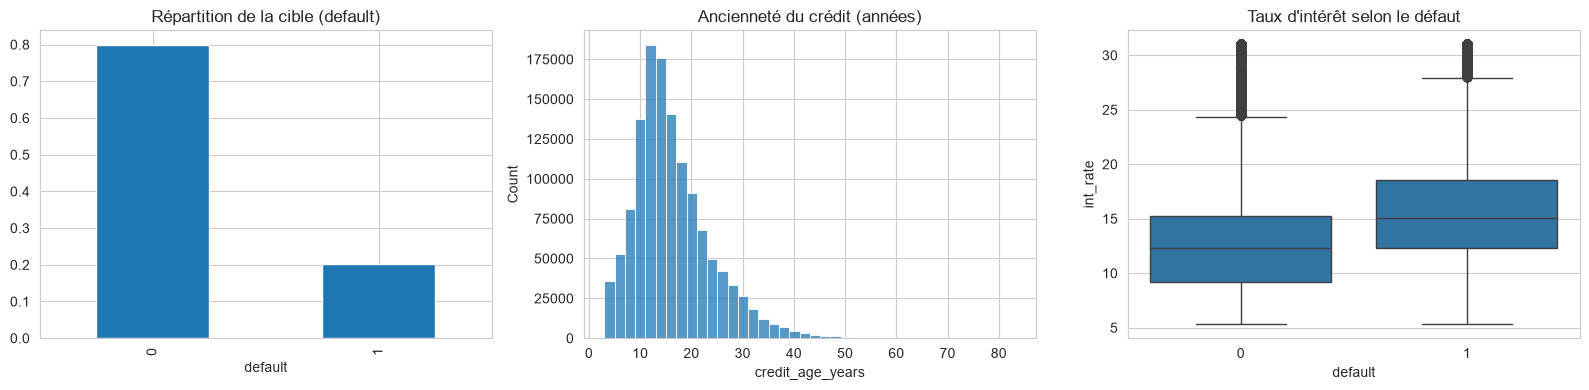

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_features["default"].value_counts(normalize=True).plot(
    kind="bar", ax=axes[0], title="Répartition de la cible (default)"
)

sns.histplot(df_features["credit_age_years"].dropna(), bins=40, ax=axes[1])
axes[1].set_title("Ancienneté du crédit (années)")

sns.boxplot(data=df_features, x="default", y="int_rate", ax=axes[2])
axes[2].set_title("Taux d'intérêt selon le défaut")

plt.tight_layout()
plt.savefig("../reports/figures/01_exploration_overview.png", dpi=150)
plt.show()

## 6. Split train/test et sauvegarde

Split chronologique (train sur les années antérieures, test sur la plus récente),
plus réaliste qu'un split aléatoire pour un scoring de crédit.

In [21]:
train = df_features[df_features["issue_d"].dt.year <= 2016].copy()
test = df_features[df_features["issue_d"].dt.year == 2017].copy()

print(f"Train : {train.shape[0]:,} lignes".replace(",", " "))
print(f"Test  : {test.shape[0]:,} lignes".replace(",", " "))
print(f"\nTaux de défaut train : {train['default'].mean():.3%}")
print(f"Taux de défaut test  : {test['default'].mean():.3%}")

train.to_parquet("../data/processed/train.parquet", index=False)
test.to_parquet("../data/processed/test.parquet", index=False)
print("\nFichiers sauvegardés dans data/processed/")

Train : 1 119 711 lignes
Test  : 169 321 lignes

Taux de défaut train : 19.698%
Taux de défaut test  : 23.133%

Fichiers sauvegardés dans data/processed/
